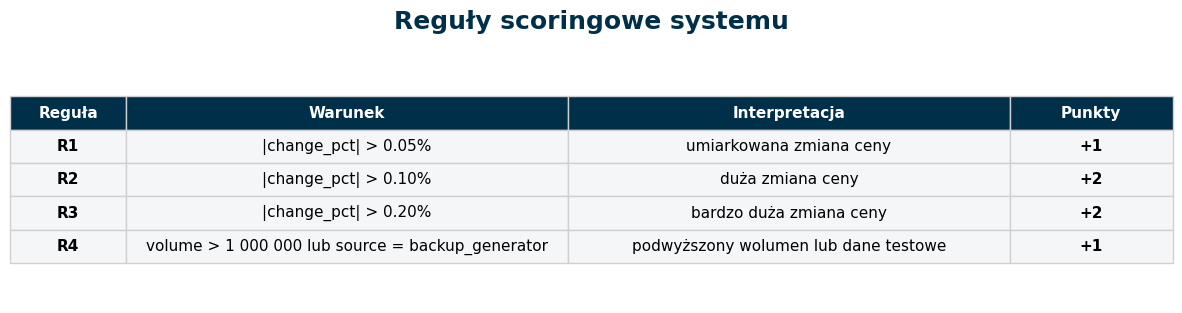

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# TABELA 1: REGUŁY SCORINGOWE

reguly = pd.DataFrame({
    "Reguła": ["R1", "R2", "R3", "R4"],
    "Warunek": [
        "|change_pct| > 0.05%",
        "|change_pct| > 0.10%",
        "|change_pct| > 0.20%",
        "volume > 1 000 000 lub source = backup_generator"
    ],
    "Interpretacja": [
        "umiarkowana zmiana ceny",
        "duża zmiana ceny",
        "bardzo duża zmiana ceny",
        "podwyższony wolumen lub dane testowe"
    ],
    "Punkty": ["+1", "+2", "+2", "+1"]
})

fig, ax = plt.subplots(figsize=(15, 3.2))
ax.axis("off")

table = ax.table(
    cellText=reguly.values,
    colLabels=reguly.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.10, 0.38, 0.38, 0.14]
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.0)

# Styl nagłówków i komórek
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#d0d0d0")
    
    if row == 0:
        cell.set_facecolor("#003049")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#f4f6f8")
        if col == 0:
            cell.set_text_props(weight="bold")
        if col == 3:
            cell.set_text_props(weight="bold")

plt.title("Reguły scoringowe systemu", fontsize=18, weight="bold", color="#003049", pad=20)

plt.savefig("reguly_scoringowe.png", dpi=300, bbox_inches="tight")
plt.show()

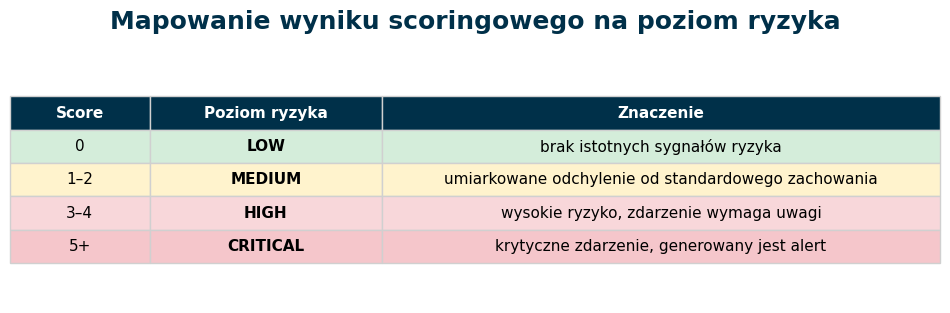

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# TABELA 2: MAPOWANIE SCORE → RYZYKO

mapowanie = pd.DataFrame({
    "Score": ["0", "1–2", "3–4", "5+"],
    "Poziom ryzyka": ["LOW", "MEDIUM", "HIGH", "CRITICAL"],
    "Znaczenie": [
        "brak istotnych sygnałów ryzyka",
        "umiarkowane odchylenie od standardowego zachowania",
        "wysokie ryzyko, zdarzenie wymaga uwagi",
        "krytyczne zdarzenie, generowany jest alert"
    ]
})

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.axis("off")

table = ax.table(
    cellText=mapowanie.values,
    colLabels=mapowanie.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.15, 0.25, 0.60]
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.0)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#d0d0d0")
    
    if row == 0:
        cell.set_facecolor("#003049")
        cell.set_text_props(color="white", weight="bold")
    else:
        risk = mapowanie.iloc[row - 1]["Poziom ryzyka"]
        
        if risk == "LOW":
            cell.set_facecolor("#d4edda")
        elif risk == "MEDIUM":
            cell.set_facecolor("#fff3cd")
        elif risk == "HIGH":
            cell.set_facecolor("#f8d7da")
        elif risk == "CRITICAL":
            cell.set_facecolor("#f5c6cb")
        
        if col == 1:
            cell.set_text_props(weight="bold")

plt.title("Mapowanie wyniku scoringowego na poziom ryzyka", fontsize=18, weight="bold", color="#003049", pad=20)

plt.savefig("mapowanie_ryzyka.png", dpi=300, bbox_inches="tight")
plt.show()